In [1]:
import io
import time

import gff3_parser
import pandas as pd
import requests
from Bio import SeqIO
import numpy as np

In [2]:
genbank_gbff = "ecoli_data/e_coli_genbank.gbff"
prokka_gbk = "../results/prokka/e_coli_prokka/e_coli.gbk"
pgap_gbk = "../results/pgap/e_coli_pgap/annot.gbk"
bakta_gbk = "../results/bakta/e_coli_bakta/e_coli.gbff"
eggnog_gff = "../results/eggnog/e_coli_eggnog/e_coli.emapper.decorated.gff"
reference_ids = []
for record in SeqIO.parse(genbank_gbff, "genbank"):
    for feature in record.features:
        if feature.type == "CDS":
            start = int(feature.location.start) + 1
            end = int(feature.location.end)
            strand = "+" if feature.location.strand == 1 else "-"
            orf_id = f"{start}_{end}_{strand}"
            protein_id = feature.qualifiers.get("protein_id", [""])[0]
            db_xrefs = feature.qualifiers.get("db_xref", [])
            for xref in db_xrefs:
                if xref.startswith("UniProt"):
                    uniprot_id = xref.split(":")[1]
            reference_ids.append({
                'orf_id': orf_id,
                'Genbank_RefSeq': protein_id,
                'Genbank_UniprotID': uniprot_id 
            })
df_gbff = pd.DataFrame(reference_ids)

prokka_ids = []
for record in SeqIO.parse(prokka_gbk, "genbank"):
    for feature in record.features:
        if feature.type == "CDS":
            start = int(feature.location.start) + 1
            end = int(feature.location.end)
            strand = "+" if feature.location.strand == 1 else "-"
            orf_id = f"{start}_{end}_{strand}"
            inference = feature.qualifiers.get("inference", [None])
            if inference:
                for inf in inference:
                    if "UniProtKB" in inf:
                        uniprotkb = inf.split(":")[2]
            prokka_ids.append({
                'orf_id': orf_id,
                'Prokka_UniProtKB': uniprotkb if uniprotkb else None
            })
df_prokka = pd.DataFrame(prokka_ids)

bakta_ids = []
for record in SeqIO.parse(bakta_gbk, "genbank"):
    for feature in record.features:
        if feature.type == "CDS":
            start = int(feature.location.start) + 1
            end = int(feature.location.end)
            strand = "+" if feature.location.strand == 1 else "-"
            orf_id = f"{start}_{end}_{strand}"
            uniprotkb = None
            for note in feature.qualifiers.get("note", []):
                if "UniRef:UniRef100" in note:
                    uniprotkb = note.split("UniRef:UniRef100_")[1]
                elif "UniRef:UniRef90" in note:
                    uniprotkb = note.split("UniRef:UniRef90_")[1]
                elif "UniRef:UniRef50" in note:
                    uniprotkb = note.split("UniRef:UniRef50_")[1]
            bakta_ids.append({
                'orf_id': orf_id,
                'Bakta_UniProtKB': uniprotkb if uniprotkb else None
            })
df_bakta = pd.DataFrame(bakta_ids)

pgap_ids = []
for record in SeqIO.parse(pgap_gbk, "genbank"):
    for feature in record.features:
        if feature.type == "CDS":
            start = int(feature.location.start) + 1
            end = int(feature.location.end)
            strand = "+" if feature.location.strand == 1 else "-"
            orf_id = f"{start}_{end}_{strand}"
            uniprotkb = None
            refseq_code = None
            inferences = feature.qualifiers.get("inference", [])
            for inference in inferences:
                if "RefSeq" in inference:
                    refseq_code = inference.split(":")[3]
                elif "motif" in inference:
                    refseq_code = inference.split(":")[3]
            pgap_ids.append({
                'orf_id': orf_id,
                'PGAP_RefSeq': refseq_code if refseq_code else None
            })
df_pgap = pd.DataFrame(pgap_ids)

eggnog_df = gff3_parser.parse_gff3(eggnog_gff, parse_attributes=True)
eggnog_df["orf_id"] = eggnog_df.apply(lambda row: f"{row['Start']}_{row['End']}_{row['Strand']}", axis=1)
eggnog_df = eggnog_df[["orf_id", "em_target"]]

 Sequence Data: seqnum=1;seqlen=4641652;seqhdr="ecoli"
 Model Data: version=Prodigal.v2.6.3;run_type=Single;model="Ab initio";gc_cont=50.79;transl_table=11;uses_sd=1
Building structured data...


100%|██████████| 4323/4323 [00:00<00:00, 729480.86it/s]


Adding Supplemental Attribute table...
Finding unique attribute keys...


100%|██████████| 4319/4319 [00:00<00:00, 271494.50it/s]


Making attribute table...


100%|██████████| 4319/4319 [00:00<00:00, 84952.96it/s]


In [3]:
df_func = pd.read_csv("ecoli_data/e_coli_concordant_CDS.csv")
df_func.drop(columns=["Start", "End", "Strand","product_Prokka","product_Bakta","product_PGAP","product_eggNOG","product_Reference"], inplace=True)
df_func = pd.merge(df_func, df_gbff, on='orf_id', how='left')
df_func = pd.merge(df_func, df_prokka, on='orf_id', how='left')
df_func = pd.merge(df_func, df_bakta, on='orf_id', how='left')
df_func = pd.merge(df_func, df_pgap, on='orf_id', how='left')
df_func = pd.merge(df_func, eggnog_df, on='orf_id', how='left')
df_func = df_func[df_func['Genbank_UniprotID'].notna()]
df_func

,orf_id,Genbank_RefSeq,Genbank_UniprotID,Prokka_UniProtKB,Bakta_UniProtKB,PGAP_RefSeq,em_target
0,190_255_+,NP_414542.1,P0AD86,NaN,P0AD86,NP_414542.1,NaN
1,337_2799_+,NP_414543.1,P00561,P00561,P00561,WP_005124053.1,511145.b0002
2,2801_3733_+,NP_414544.1,P00547,P00547,P00547,NP_414544.1,511145.b0003
3,3734_5020_+,NP_414545.1,P00934,P00934,P00934,NP_414545.1,316407.21321894
4,5234_5530_+,NP_414546.1,P75616,P00934,P75616,NP_414546.1,316407.21321895
...,...,...,...,...,...,...,...
4335,4638178_4639530_+,NP_418817.1,P08369,P08369,P08369,NP_418817.1,316407.85677139
4336,4639590_4640306_-,NP_418818.1,P0A9Q1,P0A9Q1,P0A9Q1,WP_003621071.1,469008.B21_04242
4337,4640402_4640542_+,NP_418819.1,P0ADD9,NaN,NaN,NP_418819.1,NaN
4338,4640718_4640771_+,YP_010283921.1,P0DV23,NaN,NaN,NaN,NaN


In [4]:
def uniprot_id_mapping(id_list, from_db, to_db='UniProtKB'):
    """Maps database identifiers using the UniProt REST API."""
    clean_ids = list(set([str(i).strip() for i in id_list if pd.notna(i) and str(i).strip() != '']))
    if not clean_ids:
        return pd.DataFrame()
        
    print(f"Mapping: {from_db} -> {to_db} ({len(clean_ids)} IDs)...")
    
    submit_url = 'https://rest.uniprot.org/idmapping/run'
    response = requests.post(submit_url, data={'from': from_db, 'to': to_db, 'ids': ','.join(clean_ids)})
    response.raise_for_status() 
    job_id = response.json()['jobId']
    
    status_url = f'https://rest.uniprot.org/idmapping/status/{job_id}'
    while True:
        status_res = requests.get(status_url)
        status_res.raise_for_status()
        status_data = status_res.json()
        
        if 'jobStatus' in status_data:
            if status_data['jobStatus'] in ['RUNNING', 'NEW']:
                time.sleep(2)
            elif status_data['jobStatus'] == 'ERROR':
                raise Exception(f"API Error: {status_data}")
        else:
            break
            
    result_url = f'https://rest.uniprot.org/idmapping/stream/{job_id}?format=tsv'
    result_res = requests.get(result_url)
    result_res.raise_for_status()
    
    return pd.read_csv(io.StringIO(result_res.text), sep='\t')

In [5]:
pgap_raw = df_func['PGAP_RefSeq'].dropna().apply(lambda x: str(x).replace('cds-', '')).tolist()
eggnog_raw = df_func['em_target'].dropna().tolist()

df_pgap_uniprot = uniprot_id_mapping(pgap_raw, from_db='RefSeq_Protein', to_db='UniProtKB')
df_eggnog_uniprot = uniprot_id_mapping(eggnog_raw, from_db='STRING', to_db='UniProtKB')

# Extract mapped UniProt IDs
pgap_uniprot_list = df_pgap_uniprot['To'].dropna().tolist() if not df_pgap_uniprot.empty else []
eggnog_uniprot_list = df_eggnog_uniprot['To'].dropna().tolist() if not df_eggnog_uniprot.empty else []

# Extract native UniProt IDs from other tools
bakta_uniprot_list = df_func['Bakta_UniProtKB'].dropna().tolist()
prokka_uniprot_list = df_func['Prokka_UniProtKB'].dropna().tolist()
ref_uniprot_list = df_func['Genbank_UniprotID'].dropna().tolist()

Mapping: RefSeq_Protein -> UniProtKB (4064 IDs)...


Mapping: STRING -> UniProtKB (3851 IDs)...


In [6]:
all_uniprot_ids = list(set(bakta_uniprot_list + prokka_uniprot_list + ref_uniprot_list + pgap_uniprot_list + eggnog_uniprot_list))
df_uniprot_uniref = uniprot_id_mapping(all_uniprot_ids, from_db='UniProtKB_AC-ID', to_db='UniRef100')

Mapping: UniProtKB_AC-ID -> UniRef100 (10165 IDs)...


In [7]:
dict_pgap_to_uniprot = dict(zip(df_pgap_uniprot['From'], df_pgap_uniprot['To'])) if not df_pgap_uniprot.empty else {}
dict_eggnog_to_uniprot = dict(zip(df_eggnog_uniprot['From'], df_eggnog_uniprot['To'])) if not df_eggnog_uniprot.empty else {}
dict_uniprot_to_uniref = dict(zip(df_uniprot_uniref['From'], df_uniprot_uniref['To'])) if not df_uniprot_uniref.empty else {}

In [8]:
def clean_id(val):
    return str(val).replace('cds-', '').strip() if pd.notna(val) else np.nan

# Assign Exact UniProtKB IDs
df_func['UniProt_PGAP'] = df_func['PGAP_RefSeq'].apply(lambda x: dict_pgap_to_uniprot.get(clean_id(x), np.nan))
df_func['UniProt_eggNOG'] = df_func['em_target'].apply(lambda x: dict_eggnog_to_uniprot.get(clean_id(x), np.nan))
df_func['UniProt_Bakta'] = df_func['Bakta_UniProtKB'].apply(clean_id)
df_func['UniProt_Prokka'] = df_func['Prokka_UniProtKB'].apply(clean_id)
df_func['UniProt_Reference'] = df_func['Genbank_UniprotID'].apply(clean_id)

# Assign UniRe100 Clusters
df_func['Cluster_PGAP'] = df_func['UniProt_PGAP'].apply(lambda x: dict_uniprot_to_uniref.get(x, np.nan))
df_func['Cluster_eggNOG'] = df_func['UniProt_eggNOG'].apply(lambda x: dict_uniprot_to_uniref.get(x, np.nan))
df_func['Cluster_Bakta'] = df_func['UniProt_Bakta'].apply(lambda x: dict_uniprot_to_uniref.get(x, np.nan))
df_func['Cluster_Prokka'] = df_func['UniProt_Prokka'].apply(lambda x: dict_uniprot_to_uniref.get(x, np.nan))
df_func['Cluster_Reference'] = df_func['UniProt_Reference'].apply(lambda x: dict_uniprot_to_uniref.get(x, np.nan))

,Annotation Tool,Exact UniProt Rate (%),UniRef100 Cluster Rate (%),Ref. IDs Available (100%),UniProt Matches (n),Cluster Matches (n)
0,Prokka,66.540000,67.560000,4298,2860,2901
1,Bakta,88.440000,89.710000,4298,3801,3852
2,PGAP,63.750000,81.840000,4298,2740,3514
3,eggNOG,29.130000,34.300000,4298,1252,1473


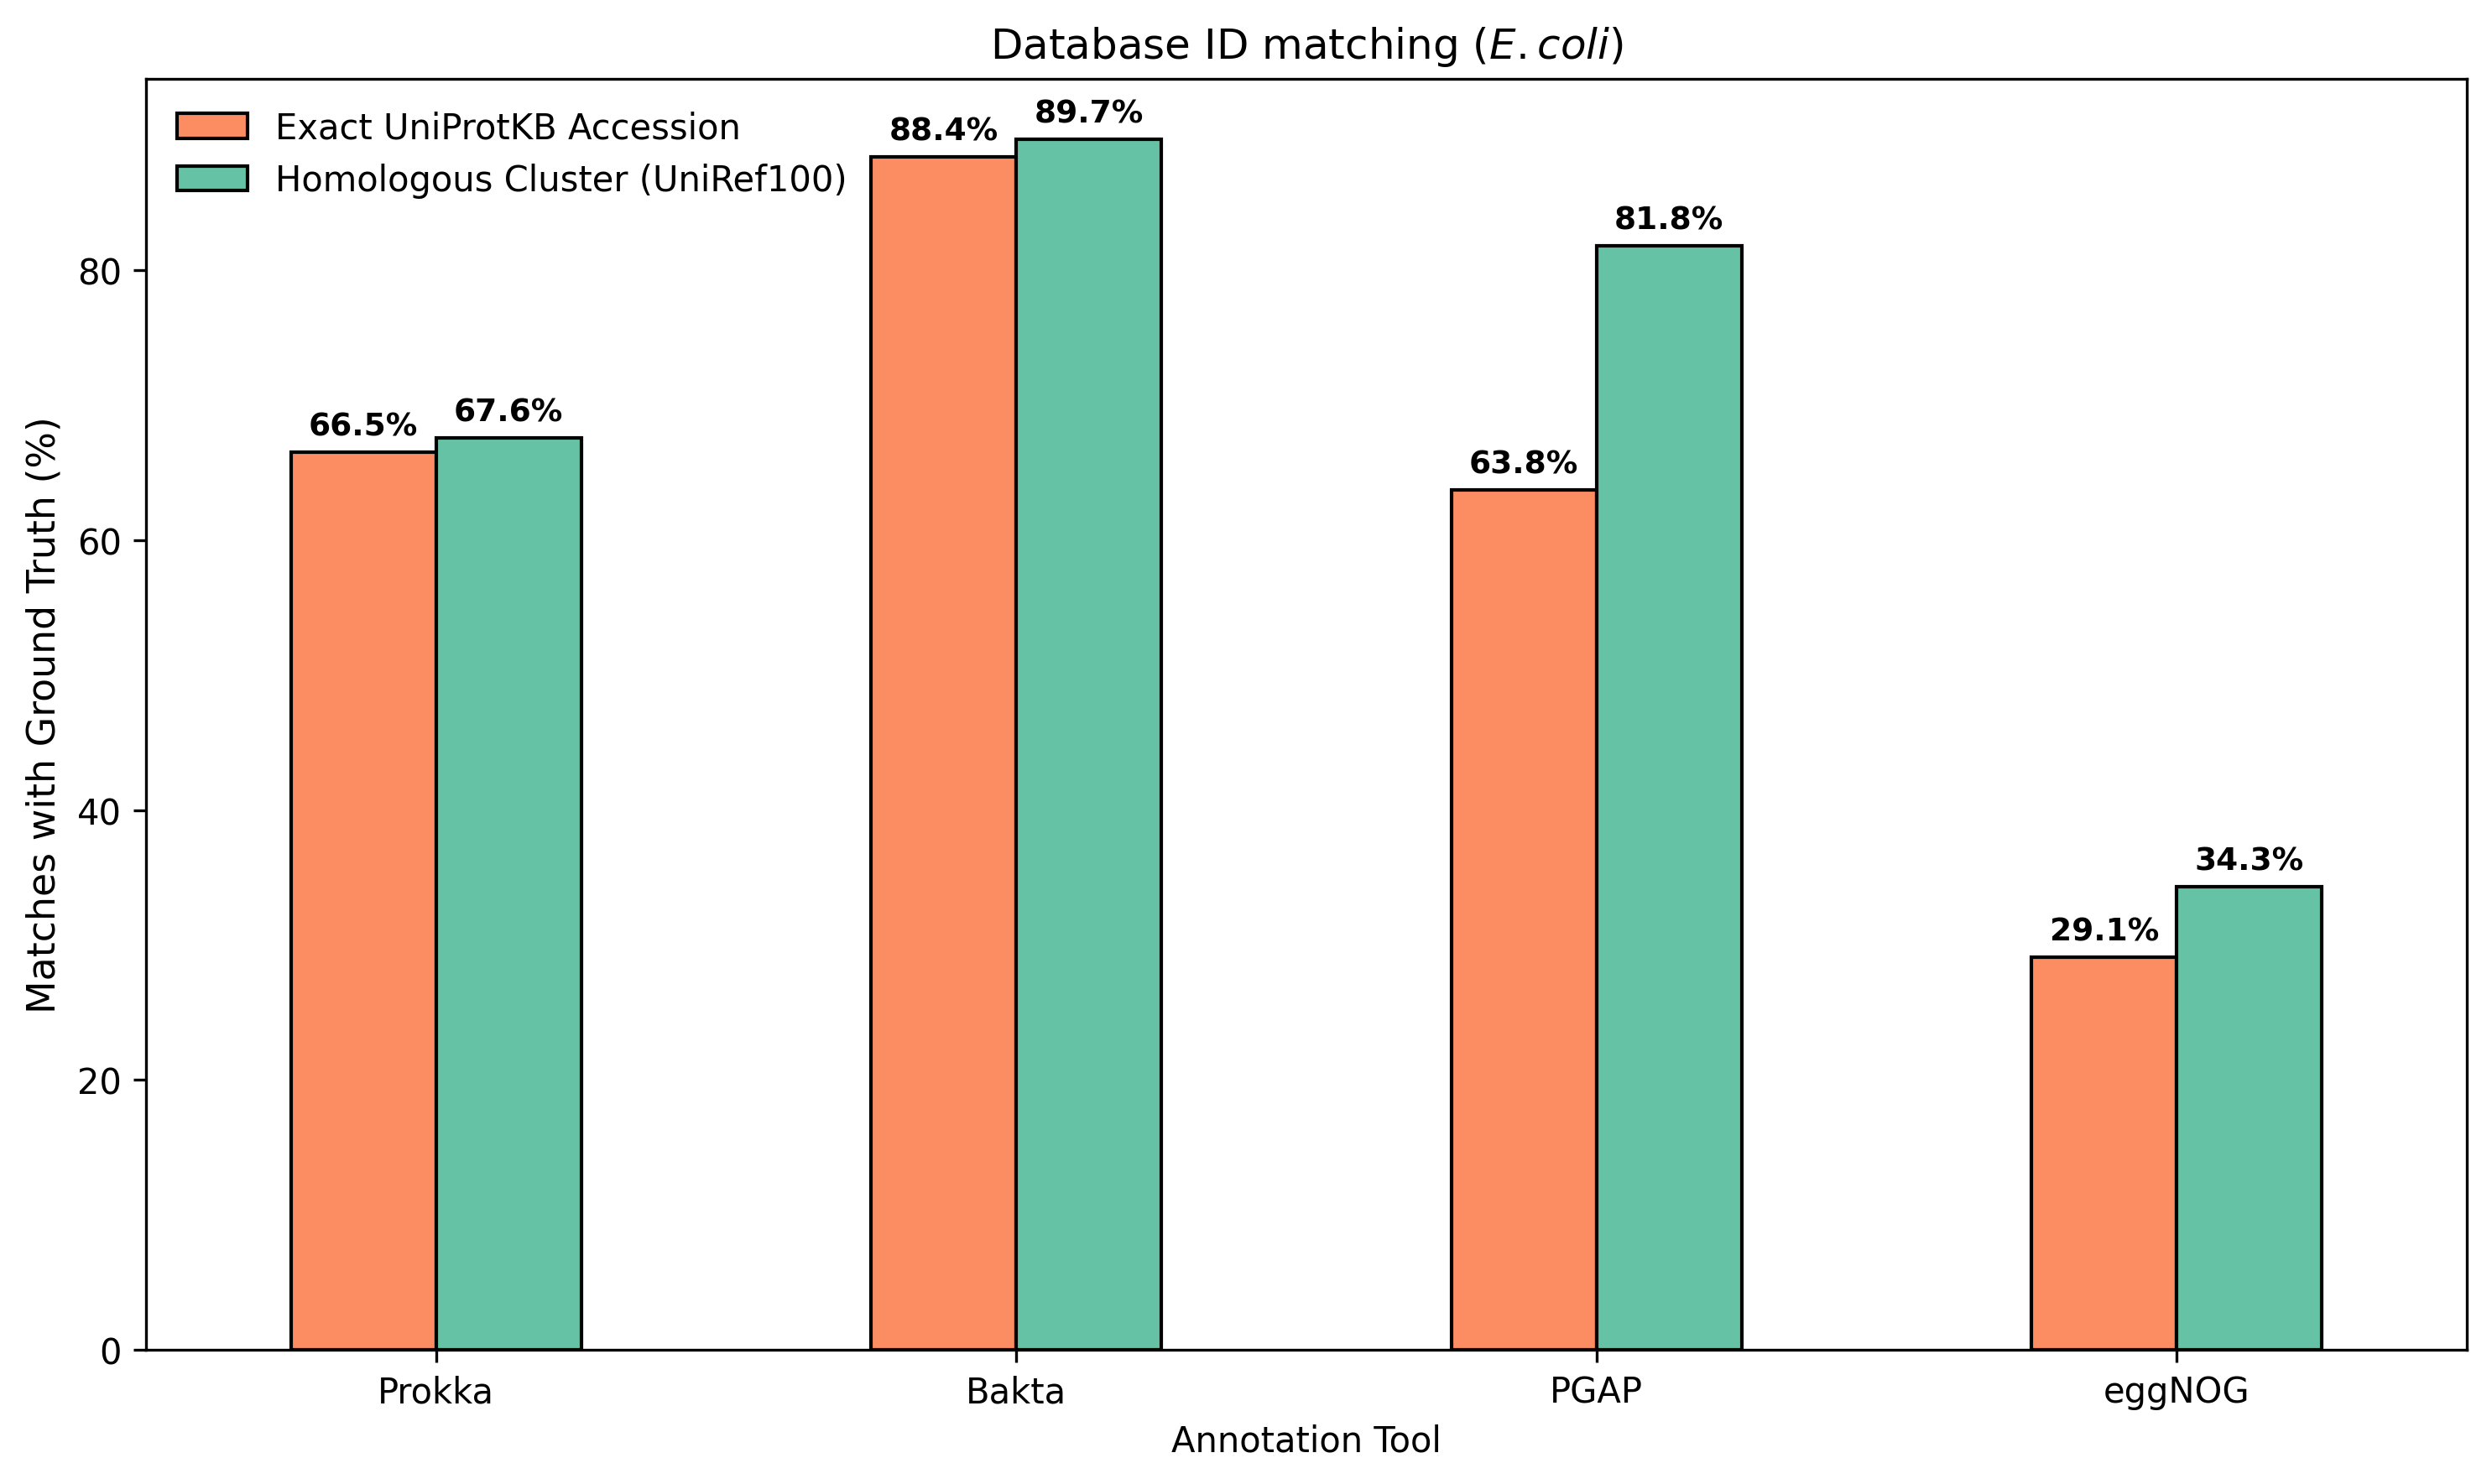

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

tools = ['Prokka', 'Bakta', 'PGAP', 'eggNOG']
results = []

total_uniprot_reference = df_func['UniProt_Reference'].notna().sum()
total_cluster_reference = df_func['Cluster_Reference'].notna().sum()

for tool in tools:
    uniprot_matches = (df_func[f'UniProt_{tool}'] == df_func['UniProt_Reference']).sum()
    
    uniprot_rate = (uniprot_matches / total_uniprot_reference) * 100 if total_uniprot_reference > 0 else 0
    
    cluster_matches = (df_func[f'Cluster_{tool}'] == df_func['Cluster_Reference']).sum()
    cluster_rate = (cluster_matches / total_cluster_reference) * 100 if total_cluster_reference > 0 else 0
    
    results.append({
        'Annotation Tool': tool,
        'Exact UniProt Rate (%)': round(uniprot_rate, 2),
        'UniRef100 Cluster Rate (%)': round(cluster_rate, 2),
        'Ref. IDs Available (100%)': total_uniprot_reference,
        'UniProt Matches (n)': uniprot_matches,
        'Cluster Matches (n)': cluster_matches
    })

df_metrics = pd.DataFrame(results)

display(df_metrics.style.background_gradient(cmap='Blues', subset=['Exact UniProt Rate (%)', 'UniRef100 Cluster Rate (%)']))


fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
df_metrics.set_index('Annotation Tool')[['Exact UniProt Rate (%)', 'UniRef100 Cluster Rate (%)']].plot(
    kind='bar', ax=ax, color=['#fc8d62', '#66c2a5'], edgecolor='black'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, fontweight='bold', padding=3)

plt.ylabel(f"Matches with Ground Truth (%)", fontsize=11)
plt.xticks(rotation=0)
plt.title("Database ID matching ($\it{E. coli}$)")
plt.legend(['Exact UniProtKB Accession', 'Homologous Cluster (UniRef100)'], loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

In [10]:
df_func

,orf_id,Genbank_RefSeq,Genbank_UniprotID,Prokka_UniProtKB,Bakta_UniProtKB,PGAP_RefSeq,em_target,UniProt_PGAP,UniProt_eggNOG,UniProt_Bakta,UniProt_Prokka,UniProt_Reference,Cluster_PGAP,Cluster_eggNOG,Cluster_Bakta,Cluster_Prokka,Cluster_Reference
0,190_255_+,NP_414542.1,P0AD86,NaN,P0AD86,NP_414542.1,NaN,P0AD86,NaN,P0AD86,NaN,P0AD86,UniRef100_P0AD86,NaN,UniRef100_P0AD86,NaN,UniRef100_P0AD86
1,337_2799_+,NP_414543.1,P00561,P00561,P00561,WP_005124053.1,511145.b0002,A0A6N6K9K7,P00561,P00561,P00561,P00561,UniRef100_A0A6N6K9K7,UniRef100_P00561,UniRef100_P00561,UniRef100_P00561,UniRef100_P00561
2,2801_3733_+,NP_414544.1,P00547,P00547,P00547,NP_414544.1,511145.b0003,P00547,P00547,P00547,P00547,P00547,UniRef100_P00547,UniRef100_P00547,UniRef100_P00547,UniRef100_P00547,UniRef100_P00547
3,3734_5020_+,NP_414545.1,P00934,P00934,P00934,NP_414545.1,316407.21321894,P00934,NaN,P00934,P00934,P00934,UniRef100_P00934,NaN,UniRef100_P00934,UniRef100_P00934,UniRef100_P00934
4,5234_5530_+,NP_414546.1,P75616,P00934,P75616,NP_414546.1,316407.21321895,P75616,NaN,P75616,P00934,P75616,UniRef100_P75616,NaN,UniRef100_P75616,UniRef100_P00934,UniRef100_P75616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,4638178_4639530_+,NP_418817.1,P08369,P08369,P08369,NP_418817.1,316407.85677139,P08369,NaN,P08369,P08369,P08369,UniRef100_P08369,NaN,UniRef100_P08369,UniRef100_P08369,UniRef100_P08369
4336,4639590_4640306_-,NP_418818.1,P0A9Q1,P0A9Q1,P0A9Q1,WP_003621071.1,469008.B21_04242,NaN,NaN,P0A9Q1,P0A9Q1,P0A9Q1,NaN,NaN,UniRef100_P0A9Q1,UniRef100_P0A9Q1,UniRef100_P0A9Q1
4337,4640402_4640542_+,NP_418819.1,P0ADD9,NaN,NaN,NP_418819.1,NaN,P0ADD9,NaN,NaN,NaN,P0ADD9,UniRef100_P0ADD9,NaN,NaN,NaN,UniRef100_P0ADD9
4338,4640718_4640771_+,YP_010283921.1,P0DV23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P0DV23,NaN,NaN,NaN,NaN,UniRef100_P0DV23
